In [4]:
import numpy as np
import pandas as pd
import galpy
import astropy
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [5]:
#NASA Exoplanet Archive
nasa = pd.read_csv("NASA exoplanet Archive (filtered Columns) 1 (Degrees).csv",
                   skiprows=30)
nasa = nasa[nasa["gaia_dr3_id"].notna()].copy()
nasa["gaia_id_clean"] = (nasa["gaia_dr3_id"]
                          .astype(str)
                          .str.replace("Gaia DR3 ", "", regex=False)
                          .str.strip())

# Drop duplicate Gaia IDs — one row per host star (multiple planets per star)
nasa = nasa.drop_duplicates(subset="gaia_id_clean", keep="first")
print(f"NASA unique host stars (deduplicated): {len(nasa):,}")

#Gaia AspGap catalogue
gaia = pd.read_csv("Gaia_data.csv")
gaia["gaia_id_clean"] = gaia["source_id"].astype(str).str.strip()

print(f"Gaia AspGap stars:{len(gaia):,}")

# Save inspection sample
gaia.head(200).to_csv("gaia_sample_200.csv", index=False)
print("\nColumns in Gaia file:")
print(list(gaia.columns))



NASA unique host stars (deduplicated): 4,205
Gaia AspGap stars:12,036,782

Columns in Gaia file:
['B_rgeo_xa', 'B_rpgeo_xa', 'aom_xp', 'b', 'b_rgeo_x', 'b_rpgeo_x', 'bp_rp', 'dec', 'e_aom_xp', 'e_logg_xp', 'e_moh_xp', 'e_teff_xp', 'l', 'logg_xp', 'moh_xp', 'parallax', 'parallax_error', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'phot_rp_mean_mag', 'pmdec', 'pmdec_error', 'pmra', 'pmra_error', 'ra', 'radial_velocity', 'radial_velocity_error', 'rgeo', 'rpgeo', 'ruwe', 'snr_rp', 'source_id', 'teff_xp', 'vx', 'vy', 'vz', 'x', 'x_dec', 'x_ra', 'y', 'z', 'gaia_id_clean']


In [6]:
nasa_gaia = nasa.merge(
    gaia,
    on="gaia_id_clean",
    how="inner",
    suffixes=("_nasa", "_gaia")
)
print(f"Combined NASA + Gaia (matched host stars): {len(nasa_gaia):,}")

# Save full Gaia catalogue for plot backgrounds
gaia.to_csv("gaia_full_catalog.csv", index=False)
print("Saved gaia_full_catalog.csv")

# Save matched file
nasa_gaia.to_csv("exoplanet_hosts_gaia_NASA_matched.csv", index=False)
print("Saved exoplanet_hosts_gaia_NASA_matched.csv")

Combined NASA + Gaia (matched host stars): 147
Saved gaia_full_catalog.csv
Saved exoplanet_hosts_gaia_NASA_matched.csv


In [7]:
#Quality cuts 

# Resolve parallax column name (may be parallax_gaia after merge if NASA also has one)
plx_col    = "parallax_gaia" if "parallax_gaia" in nasa_gaia.columns else "parallax"
plxerr_col = "parallax_error_gaia" if "parallax_error_gaia" in nasa_gaia.columns else "parallax_error"

nasa_gaia["plx_frac_err"] = nasa_gaia[plxerr_col] / nasa_gaia[plx_col]

clean_hosts = nasa_gaia[
    (nasa_gaia["ruwe"].isna()         | (nasa_gaia["ruwe"]         <= 1.2))  &
    (nasa_gaia["snr_rp"].isna()       | (nasa_gaia["snr_rp"]       > 20))   &
    (nasa_gaia["teff_xp"].isna()      | (nasa_gaia["teff_xp"].between(3500, 6800))) &
    (nasa_gaia[plx_col].isna()        | (nasa_gaia[plx_col]        > 0))    &
    (nasa_gaia["plx_frac_err"].isna() | (nasa_gaia["plx_frac_err"] <= 0.20))
].copy()

print(f"After quality cuts (host stars): {len(clean_hosts):,} rows")
print(f"Retention: {100 * len(clean_hosts) / len(nasa_gaia):.1f}%")

# Apply same cuts to full Gaia catalogue (survey background for plots)
gaia_all = pd.read_csv("gaia_full_catalog.csv")
gaia_all = gaia_all.replace(-9999.0, np.nan)

gaia_clean = gaia_all[
    (gaia_all["ruwe"].isna()    | (gaia_all["ruwe"]    <= 1.2))  &
    (gaia_all["snr_rp"].isna()  | (gaia_all["snr_rp"]  > 20))   &
    (gaia_all["teff_xp"].isna() | (gaia_all["teff_xp"].between(3500, 6800)))
].copy()

print(f"\nFull Gaia after quality cuts: {len(gaia_clean):,} rows")
print(f"Retention: {100 * len(gaia_clean) / len(gaia_all):.1f}%")


After quality cuts (host stars): 138 rows
Retention: 93.9%

Full Gaia after quality cuts: 11,033,800 rows
Retention: 91.7%


In [8]:

# Select stars with valid RV and positive parallax
orbit_sample = clean_hosts[
    clean_hosts["radial_velocity"].notna() &
    (clean_hosts[plx_col] > 0)
].copy().reset_index(drop=True)

n = len(orbit_sample)
print(f"Stars with valid RV & parallax: {n}")

# Initialise output arrays
v_x_galcen     = np.full(n, np.nan)
v_y_galcen     = np.full(n, np.nan)
v_z_galcen     = np.full(n, np.nan)
v_total_galcen = np.full(n, np.nan)
Lz             = np.full(n, np.nan)
ecc            = np.full(n, np.nan)
E              = np.full(n, np.nan)
X_galcen       = np.full(n, np.nan)
Y_galcen       = np.full(n, np.nan)
Z_galcen       = np.full(n, np.nan)
r_apo          = np.full(n, np.nan)
r_peri         = np.full(n, np.nan)
z_max          = np.full(n, np.nan)

for i in range(n):
    try:
        o = Orbit(
            [
                orbit_sample['ra_nasa'].iloc[i],
                orbit_sample['dec_nasa'].iloc[i],
                1.0 / orbit_sample['sy_plx'].iloc[i],
                orbit_sample["sy_pmra"].iloc[i],
                orbit_sample["sy_pmdec"].iloc[i],
                orbit_sample["radial_velocity"].iloc[i],
            ],
            radec=True, solarmotion="schoenrich", ro=8.0, vo=220,
        )
        v_x_galcen[i]     = o.vx(use_physical=True)
        v_y_galcen[i]     = o.vy(use_physical=True)
        v_z_galcen[i]     = o.vz(use_physical=True)
        v_total_galcen[i] = np.sqrt(v_x_galcen[i]**2 + v_y_galcen[i]**2 + v_z_galcen[i]**2)
        Lz[i]             = o.Lz(use_physical=True)
        ecc[i]            = o.e(use_physical=True, pot=MWPotential2014, analytic=True)
        E[i]              = o.E(use_physical=True, pot=MWPotential2014)
        X_galcen[i]       = o.x(use_physical=True)
        Y_galcen[i]       = o.y(use_physical=True)
        Z_galcen[i]       = o.z(use_physical=True)
        r_apo[i]          = o.rap(use_physical=True,  pot=MWPotential2014, analytic=True)
        r_peri[i]         = o.rperi(use_physical=True, pot=MWPotential2014, analytic=True)
        z_max[i]          = o.zmax(use_physical=True, pot=MWPotential2014, analytic=True)
    except Exception as e:
        print(f"Error at star {i}: {e}")

print(f"Orbits computed for {(~np.isnan(Lz)).sum()} / {n} stars")

# Attach orbit columns to orbit_sample
orbit_sample["v_x_galcen"]     = v_x_galcen
orbit_sample["v_y_galcen"]     = v_y_galcen
orbit_sample["v_z_galcen"]     = v_z_galcen
orbit_sample["v_total_galcen"] = v_total_galcen
orbit_sample["Lz_orbit"]       = Lz
orbit_sample["e_orbit"]        = ecc
orbit_sample["E_orbit"]        = E
orbit_sample["X_galcen"]       = X_galcen
orbit_sample["Y_galcen"]       = Y_galcen
orbit_sample["Z_galcen"]       = Z_galcen
orbit_sample["r_apo"]          = r_apo
orbit_sample["r_peri"]         = r_peri
orbit_sample["z_max"]          = z_max

# Merge back into clean_hosts (NaN for stars without valid RV)
orbit_cols = [
    "gaia_id_clean",
    "v_x_galcen", "v_y_galcen", "v_z_galcen", "v_total_galcen",
    "Lz_orbit", "e_orbit", "E_orbit",
    "X_galcen", "Y_galcen", "Z_galcen",
    "r_apo", "r_peri", "z_max",
]
clean_hosts = clean_hosts.merge(orbit_sample[orbit_cols], on="gaia_id_clean", how="left")

clean_hosts.to_csv("exoplanet_hosts_gaia_with_orbits.csv", index=False)
print("Saved exoplanet_hosts_gaia_with_orbits.csv")

Stars with valid RV & parallax: 138
Orbits computed for 138 / 138 stars
Saved exoplanet_hosts_gaia_with_orbits.csv


In [9]:
# MONTE CARLO UNCERTAINTIES FOR TOOMRE DIAGRAM ONLY

N_MC = 1000

vygalcen    = np.full(n, np.nan)
vy_err      = np.full(n, np.nan)
vperp       = np.full(n, np.nan)
vperp_err   = np.full(n, np.nan)

for i in range(n):
    try:
        row = orbit_sample.iloc[i]
        vxs, vys, vzs = [], [], []

        plx_samples  = np.random.normal(row['sy_plx'],   row['sy_plxerr1'],   N_MC)
        pmra_samples = np.random.normal(row['sy_pmra'],  row['sy_pmraerr1'],  N_MC)
        pmde_samples = np.random.normal(row['sy_pmdec'], row['sy_pmdecerr1'], N_MC)
        rv_samples   = np.random.normal(row['radial_velocity'],    row['radial_velocity_error'],    N_MC)

        for j in range(N_MC):
            if plx_samples[j] <= 0:
                continue
            try:
                o = Orbit(
                    [row['ra_nasa'], row['dec_nasa'],
                     1.0 / plx_samples[j],
                     pmra_samples[j], pmde_samples[j], rv_samples[j]],
                    radec=True, solarmotion='schoenrich', ro=8.0, vo=220,
                )
                vxs.append(o.vx(use_physical=True))
                vys.append(o.vy(use_physical=True))
                vzs.append(o.vz(use_physical=True))
            except Exception:
                continue

        if len(vys) < 10:
            continue

        # Vy: median + 1-sigma from 16th/84th percentiles
        p16, p50, p84 = np.percentile(vys, [16, 50, 84])
        vygalcen[i] = p50
        vy_err[i]   = (p84 - p16) / 2

        # Vperp = sqrt(Vx^2 + Vz^2): median + uncertainty
        vperp_arr = np.sqrt(np.array(vxs)**2 + np.array(vzs)**2)
        p16, p50, p84 = np.percentile(vperp_arr, [16, 50, 84])
        vperp[i]     = p50
        vperp_err[i] = (p84 - p16) / 2

    except Exception as e:
        print(f"Error at star {i}: {e}")

# Attach to orbit_sample
orbit_sample['vygalcen']  = vygalcen
orbit_sample['vy_err']    = vy_err
orbit_sample['vperp']     = vperp
orbit_sample['vperp_err'] = vperp_err

# Per-survey uncertainty summary
valid = ~np.isnan(vy_err)
print("  Gaia — Toomre Diagram Kinematic Uncertainties")
print(f"  N stars with valid MC runs : {valid.sum()} / {n}")
print(f"  Median sigma(V_Y)              : {np.nanmedian(vy_err):.3f} km/s")
print(f"  Median sigma(V_perp)           : {np.nanmedian(vperp_err):.3f} km/s")



  Gaia — Toomre Diagram Kinematic Uncertainties
  N stars with valid MC runs : 138 / 138
  Median sigma(V_Y)              : 0.149 km/s
  Median sigma(V_perp)           : 0.220 km/s


 plot1_alpha_moh_gaia.png


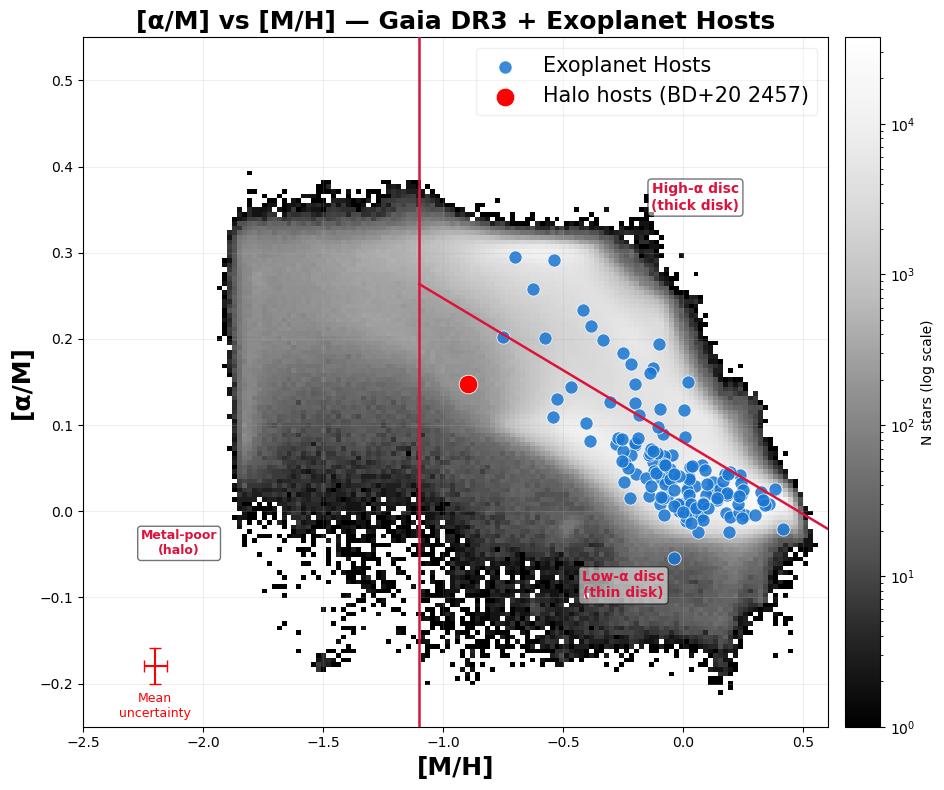

 plot2_toomre_gaia.png


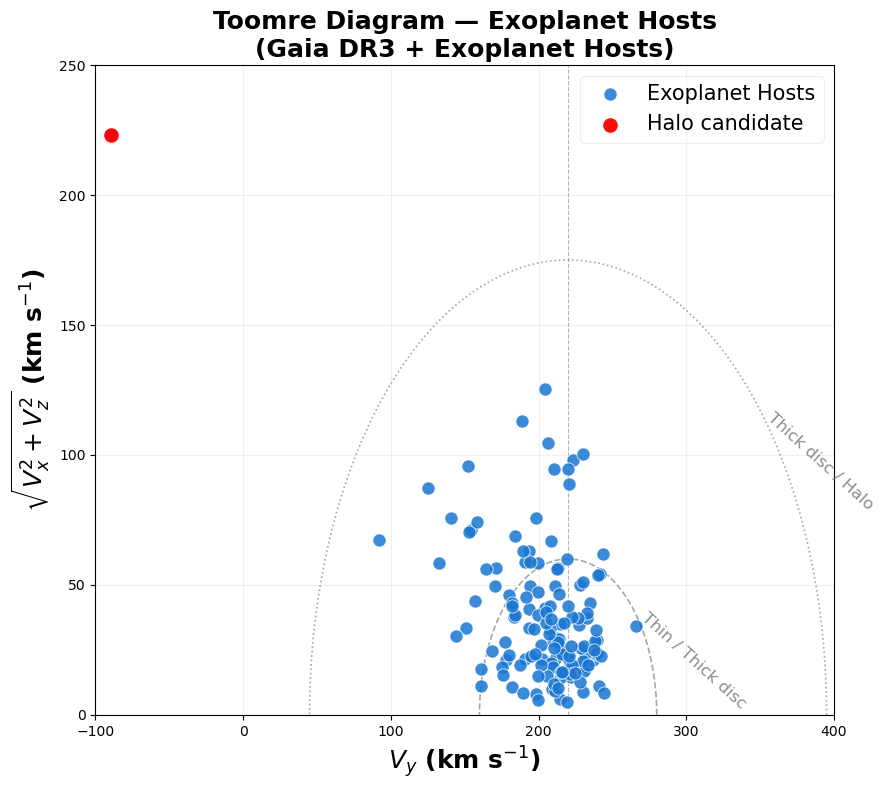

 plot3_galactic_position_gaia.png


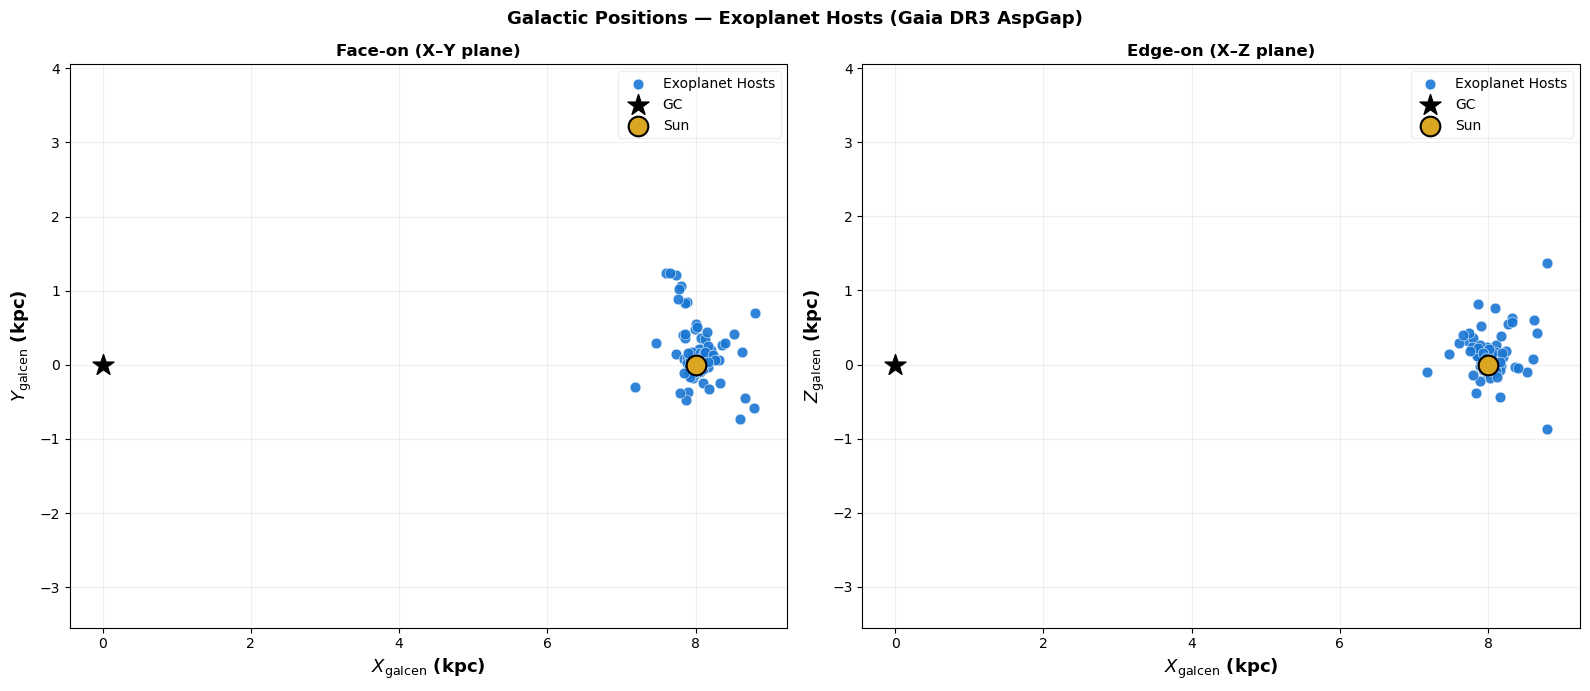

In [10]:
# Chemical Classification boundary parameters 
FEH_CUT    = -1.1
DIAG_SLOPE = -0.167
DIAG_INT   =  0.08


#Plot 1: chemical classification

#Plotting Halo star found kinematic, 

bg = gaia_clean.dropna(subset=["moh_xp", "aom_xp"])

fig, ax = plt.subplots(figsize=(10, 8))
h = ax.hist2d(bg["moh_xp"], bg["aom_xp"],
              bins=150, range=[[-2.5, 0.6], [-0.25, 0.55]],
              cmap="Greys_r", norm=LogNorm(), zorder=1)
plt.colorbar(h[3], ax=ax, label="N stars (log scale)", pad=0.02)

g = clean_hosts.dropna(subset=["moh_xp", "aom_xp"])
g["V_perp"] = np.sqrt(g["v_x_galcen"]**2 + g["v_z_galcen"]**2)
mask_halo  = (g["V_perp"] >= 175) | (g["v_y_galcen"] < 0)
ax.scatter(g["moh_xp"], g["aom_xp"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")
ax.scatter(g.loc[mask_halo,  "moh_xp"], g.loc[mask_halo,  "aom_xp"],
           c="red", marker="o", s=180, edgecolors="white",
           linewidths=0.6, zorder=6, alpha=1.0, label="Halo hosts (BD+20 2457)")

# Representative error cross - bottom-left corner
ax.errorbar(-2.2, -0.18,
            xerr=0.048, yerr=0.021,
            fmt='none', color='red', capsize=4,
            linewidth=1.5, zorder=10)
ax.text(-2.2, -0.21, 'Mean\nuncertainty',
        ha='center', va='top', fontsize=9, color='red')

# Approximate boundary lines (drawn in [M/H] space)
ax.axvline(FEH_CUT, color="crimson", lw=1.8, ls="-", zorder=6)
feh_diag = np.linspace(FEH_CUT, 0.6, 300)
ax.plot(feh_diag, DIAG_SLOPE * feh_diag + DIAG_INT,
        color="crimson", lw=1.8, ls="-", zorder=6)


ax.text(0.05,  0.35, "High-α disc\n(thick disk)",
        color="crimson", fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))
ax.text( -0.25, -0.1, "Low-α disc\n(thin disk)",
        color="crimson", fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))
ax.text(-2.1, -0.05, "Metal-poor\n(halo)",
        color="crimson", fontsize=9, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))

ax.set_xlabel("[M/H]",  fontsize=18, fontweight="bold")
ax.set_ylabel("[α/M]",  fontsize=18, fontweight="bold")
ax.set_title("[α/M] vs [M/H] — Gaia DR3 + Exoplanet Hosts",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot1_alpha_moh_gaia.png", dpi=300, bbox_inches="tight")
print(" plot1_alpha_moh_gaia.png")
plt.show()



# PLOT 2 — Toomre Diagram
# Boundary circles at 60 km/s (thin/thick disc) and 175 km/s (thick disc/halo).

clean_hosts["V_perp"] = np.sqrt(
    clean_hosts["v_x_galcen"]**2 + clean_hosts["v_z_galcen"]**2
)

V_LSR = 220.0  # km/s

fig, ax = plt.subplots(figsize=(9, 8))

g = clean_hosts.dropna(subset=["v_y_galcen", "V_perp"])
ax.scatter(g["v_y_galcen"], g["V_perp"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")

halo_mask = g["V_perp"] > 175.0
g_halo  = g[halo_mask]

#PLOT HALO CANDIDATE(S) (RED, ON TOP)
ax.scatter(g_halo["v_y_galcen"], g_halo["V_perp"],
           c="red", marker="o",
           s=130, edgecolors="white", linewidths=0.9,
           zorder=6, alpha=0.95,
           label="Halo candidate")

for v_bound, ls, pop_label in [
    ( 60, "--", "Thin / Thick disc"),
    (175, ":",  "Thick disc / Halo"),
]:
    theta = np.linspace(0, np.pi, 300)
    ax.plot(V_LSR + v_bound * np.cos(theta),
            v_bound * np.sin(theta),
            color="grey", ls=ls, lw=1.2, alpha=0.7)
#Place label on the arc at chosen angle
    angle_deg = 42
    angle_rad = np.radians(angle_deg)
    lx = V_LSR + v_bound * np.cos(angle_rad)
    ly = v_bound * np.sin(angle_rad)
    ax.text(lx + 3, ly, pop_label,
            color="grey", fontsize=12, alpha=0.9,
            rotation=-angle_deg,
            ha="left", va="top")

ax.axvline(V_LSR, color="grey", lw=0.8, alpha=0.6, ls="--")
ax.set_ylim(0,250)
ax.set_xlim(-100,400)
ax.set_xlabel(r"$V_y$ (km s$^{-1}$)", fontsize=18, fontweight="bold")
ax.set_ylabel(r"$\sqrt{V_x^2 + V_z^2}$ (km s$^{-1}$)", fontsize=18, fontweight="bold")
ax.set_title("Toomre Diagram — Exoplanet Hosts\n"
             "(Gaia DR3 + Exoplanet Hosts)",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot2_toomre_gaia_poster.png", dpi=300, bbox_inches="tight")
print(" plot2_toomre_gaia.png")
plt.show()



# PLOT 3 — Galactic Positions: face-on (X–Y) and edge-on (X–Z)

hvalid = clean_hosts.dropna(subset=["X_galcen", "Y_galcen", "Z_galcen"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

panels = [
    ("X_galcen", "Y_galcen",
     r"$X_\mathrm{galcen}$ (kpc)", r"$Y_\mathrm{galcen}$ (kpc)",
     "Face-on (X–Y plane)"),
    ("X_galcen", "Z_galcen",
     r"$X_\mathrm{galcen}$ (kpc)", r"$Z_\mathrm{galcen}$ (kpc)",
     "Edge-on (X–Z plane)"),
]

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, panels):
    ax.scatter(hvalid[xcol], hvalid[ycol],
               c="#1976d2", marker="o", s=60,
               edgecolors="white", linewidths=0.4,
               alpha=0.9, zorder=4, label="Exoplanet Hosts")
    ax.scatter(0,   0, c="black",     s=250, marker="*",  zorder=10, label="GC")
    ax.scatter(8.0, 0, c="goldenrod", s=200, marker="o",  zorder=10,
               edgecolors="black", linewidths=1.5, label="Sun")
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold")
    ax.set_title(title,   fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.3)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle("Galactic Positions — Exoplanet Hosts (Gaia DR3 AspGap)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_galactic_position_gaia.png", dpi=300, bbox_inches="tight")
print(" plot3_galactic_position_gaia.png")
plt.show()


In [14]:
#Chemical classification
chem = clean_hosts.dropna(subset=["moh_xp", "aom_xp"]).copy()
n_chem = len(chem)

def chem_class(moh, aom):
    if moh < FEH_CUT:
        return "Halo (metal-poor)"
    elif aom > DIAG_SLOPE * moh + DIAG_INT:
        return "Thick disc (high-alpha)"
    else:
        return "Thin disc (low-alpha)"

chem["chem_pop"] = chem.apply(lambda r: chem_class(r["moh_xp"], r["aom_xp"]), axis=1)


print(f"Stars with valid [M/H] & [alpha/M]: {n_chem}\n")
for label, grp in chem.groupby("chem_pop"):
    pct = 100 * len(grp) / n_chem
    print(f"  {label:<30} N={len(grp):>4} ({pct:.1f}%)")

#Kinematic classification
VLSR         = 220.0
V_THIN_THICK =  60.0
V_THICK_HALO = 175.0

kin = clean_hosts.dropna(subset=["v_x_galcen", "v_y_galcen", "v_z_galcen"]).copy()
n_kin = len(kin)

kin["V_perp"]   = np.sqrt(kin["v_x_galcen"]**2 + kin["v_z_galcen"]**2)
kin["V_toomre"] = np.sqrt((kin["v_y_galcen"] - VLSR)**2 + kin["V_perp"]**2)

def kin_class(v):
    if v < V_THIN_THICK:
        return "Thin disc"
    elif v < V_THICK_HALO:
        return "Thick disc"
    else:
        return "Halo"

kin["kin_pop"] = kin["V_toomre"].apply(kin_class)


print(f"Stars with valid kinematics: {n_kin}\n")
for label, grp in kin.groupby("kin_pop"):
    pct = 100 * len(grp) / n_kin
    print(f"  {label:<14} N={len(grp):>4} ({pct:.1f}%)")

#Save final catalogue
clean_hosts.to_csv("exoplanet_hosts_gaia_final.csv", index=False)
print("\nSaved exoplanet_hosts_gaia_final.csv")

Stars with valid [M/H] & [alpha/M]: 138

  Thick disc (high-alpha)        N=  21 (15.2%)
  Thin disc (low-alpha)          N= 117 (84.8%)
Stars with valid kinematics: 138

  Halo           N=   1 (0.7%)
  Thick disc     N=  35 (25.4%)
  Thin disc      N= 102 (73.9%)

Saved exoplanet_hosts_gaia_final.csv


In [12]:
clean_hosts[clean_hosts['v_y_galcen']<0]


,pl_name,hostname,gaia_dr3_id,sy_snum,sy_pnum,pl_controv_flag,sy_refname,ra_nasa,dec_nasa,sy_pmra,...,Lz_orbit,e_orbit,E_orbit,X_galcen,Y_galcen,Z_galcen,r_apo,r_peri,z_max,V_perp
7,BD+20 2457 b,BD+20 2457,Gaia DR3 625137162857354880,1,2,0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,154.186782,19.891263,-36.0773,...,-663.633172,0.778462,-31306.681054,8.791484,-0.578549,1.373789,16.513585,2.057052,9.75718,223.160169


In [13]:
#Average chemical uncertainties (AspGap / Gaia XP)
feh_unc_avg   = clean_hosts["e_moh_xp"].dropna().mean()
feh_unc_n     = clean_hosts["e_moh_xp"].dropna().count()

alpha_unc_avg = clean_hosts["e_aom_xp"].dropna().mean()
alpha_unc_n   = clean_hosts["e_aom_xp"].dropna().count()

print(f"  [M/H]    mean: {feh_unc_avg:.4f} dex,  N={feh_unc_n}")
print(f"  [alpha/M]    mean: {alpha_unc_avg:.4f} dex,  N={alpha_unc_n}")

  [M/H]    mean: 0.0479 dex,  N=138
  [alpha/M]    mean: 0.0205 dex,  N=138
